**[Text 01]**

# Self-Play Without Self-Deception

A toy population shows why training only against the latest checkpoint forgets old opponents, then a verifier experiment turns the Variance Inequality's qualitative lesson into an auditable signal/noise test.

Companions: [Self-Play Explained](https://artifocial.com/blog/self-play-explained-2026-sep-04), the basics piece this notebook implements, and the W35 flagship [The Game Inside the Network](https://artifocial.com/blog/game-inside-the-network-2026-aug-28). Theory source: [Self-Improving AI Agents through Self-Play](https://arxiv.org/abs/2512.02731). Runtime: under one minute on CPU.

In [1]:
# [Code 01]
import shutil
import subprocess
import sys

# uv-first: use uv if available, fall back to pip
if shutil.which("uv"):
    subprocess.check_call(["uv", "pip", "install", "--quiet", "--system", "numpy", "matplotlib"])
else:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "numpy", "matplotlib"])

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Setup complete!")
print(f"NumPy version: {np.__version__}")


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /private/tmp/art1536-nbqa/bin/python -m pip install --upgrade pip


Setup complete!
NumPy version: 2.5.2


**[Text 02]**

## The strategic environment

Our agent chooses a mixture over rock, paper, and scissors. A softmax parameterization keeps the strategy valid. At each round, the updater moves probability toward a best response to its training opponent. We compare two curricula: the latest checkpoint only, and a uniform pool of all earlier checkpoints. In this symmetric zero-sum game the Nash value is zero, so we use the best-response payoff $\max_a (Ap)_a$ against policy $p$ as exploitability; zero means no profitable pure-action deviation.

In [2]:
# [Code 02]
A = np.array([[0.0, -1.0, 1.0], [1.0, 0.0, -1.0], [-1.0, 1.0, 0.0]])
labels = np.array(["rock", "paper", "scissors"])

def softmax(logits):
    z = logits - np.max(logits)
    e = np.exp(z)
    return e / e.sum()

def exploitability(p):
    # Symmetric zero-sum game with Nash value 0: best-response payoff against p.
    return np.max(A @ p)

def train_response(opponent, start, updates=30, lr=.35, entropy=.03):
    logits = np.log(np.clip(start, 1e-8, None))
    rewards = A @ opponent
    for _ in range(updates):
        p = softmax(logits)
        # Exact policy-gradient Jacobian times action rewards, plus mild entropy pressure.
        grad = p * (rewards - p @ rewards)
        grad += entropy * (1 / len(p) - p)
        logits += lr * grad
    return softmax(logits)

print("Uniform strategy exploitability:", exploitability(np.ones(3) / 3))

Uniform strategy exploitability: 0.0


In [3]:
# [Code 03]
def run_self_play(curriculum, rounds=36):
    population = [np.array([0.72, 0.18, 0.10])]
    for _ in range(rounds):
        if curriculum == "latest":
            opponent = population[-1]
        elif curriculum == "pool":
            opponent = np.mean(population, axis=0)
        else:
            raise ValueError(curriculum)
        population.append(train_response(opponent, population[-1]))
    population = np.array(population)
    pool_means = np.cumsum(population, axis=0) / np.arange(1, len(population) + 1)[:, None]
    return population, pool_means

runs = {name: run_self_play(name) for name in ["latest", "pool"]}
for name, (checkpoints, pool_means) in runs.items():
    print(f"{name:6s}: final={np.round(checkpoints[-1], 3)}, final exploit={exploitability(checkpoints[-1]):.3f}, pool exploit={exploitability(pool_means[-1]):.3f}")

latest: final=[0.876 0.084 0.04 ], final exploit=0.836, pool exploit=0.024
pool  : final=[0.954 0.009 0.038], final exploit=0.916, pool exploit=0.382


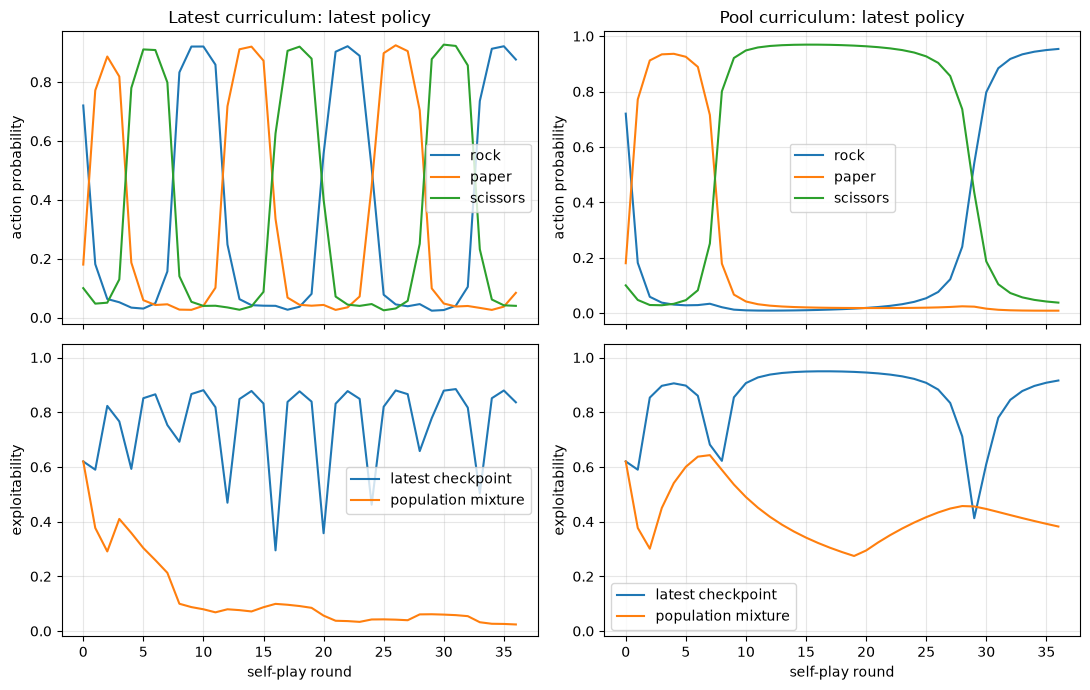

latest: the population mixture is less exploitable than the final checkpoint.
pool: the population mixture is less exploitable than the final checkpoint.


In [4]:
# [Result 01]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for col, (name, (checkpoints, pool_means)) in enumerate(runs.items()):
    for i, label in enumerate(labels):
        axes[0, col].plot(checkpoints[:, i], label=label)
    axes[0, col].set(title=f"{name.title()} curriculum: latest policy", ylabel="action probability")
    latest_eps = [exploitability(p) for p in checkpoints]
    pool_eps = [exploitability(p) for p in pool_means]
    axes[1, col].plot(latest_eps, label="latest checkpoint")
    axes[1, col].plot(pool_eps, label="population mixture")
    axes[1, col].set(xlabel="self-play round", ylabel="exploitability", ylim=(-.02, 1.05))
for ax in axes.flat:
    ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()
for name, (checkpoints, pool_means) in runs.items():
    better = exploitability(pool_means[-1]) < exploitability(checkpoints[-1])
    print(f"{name}: the population mixture is {'less' if better else 'not less'} exploitable than the final checkpoint.")

**[Callout 01]**

> **Engineering Callout #1: Recent win rate can hide forgetting**
>
> A best response can look excellent against yesterday's policy and remain trivial to exploit by an older strategy. We therefore retain every checkpoint and evaluate both the final policy and the population mixture—the uniform empirical mean of all checkpoints retained so far. In larger systems, use a bounded reservoir or a deliberately diverse league rather than silently discarding history.

**[Text 03]**

## Verifier signal versus verifier variance

The Variance Inequality is a spectral condition that the paper proves *sufficient*, under mild regularity, for the stability of self-improvement — a sufficient condition, not a characterization. We will not claim to reproduce that theorem with a toy. Instead, we stage its operational lesson: an update helps when verifier scores align with external capability, and large or correlated verifier noise can reverse the selected direction.

Candidates are small moves from a policy toward each pure action. External improvement is the reduction in exploitability. A verifier observes that improvement through noise; the updater selects the highest verifier score.

In [5]:
# [Code 04]
base = np.array([0.58, 0.30, 0.12])
step = 0.18
candidates = np.array([(1 - step) * base + step * np.eye(3)[i] for i in range(3)])
external_gain = exploitability(base) - np.array([exploitability(p) for p in candidates])
for label, policy, gain in zip(labels, candidates, external_gain):
    print(f"move toward {label:8s}: policy={np.round(policy, 3)}, external gain={gain:+.3f}")
print("Truly best candidate:", labels[np.argmax(external_gain)])

move toward rock    : policy=[0.656 0.246 0.098], external gain=-0.097
move toward paper   : policy=[0.476 0.426 0.098], external gain=+0.083
move toward scissors: policy=[0.476 0.246 0.278], external gain=+0.263
Truly best candidate: scissors


In [6]:
# [Code 05]
def verifier_trials(noise_std, bias=None, trials=4000, seed=0):
    rng = np.random.default_rng(seed)
    bias = np.zeros(3) if bias is None else np.asarray(bias)
    scores = external_gain + bias + rng.normal(0, noise_std, size=(trials, 3))
    chosen = np.argmax(scores, axis=1)
    realized = external_gain[chosen]
    return {"positive_rate": np.mean(realized > 0),
            "mean_gain": realized.mean(),
            "selection": np.bincount(chosen, minlength=3) / trials}

noise_levels = np.linspace(0, .35, 36)
clean = [verifier_trials(s, seed=10) for s in noise_levels]
# A correlated blind spot: the verifier systematically over-scores the harmful rock move.
biased = [verifier_trials(s, bias=[.16, 0, 0], seed=10) for s in noise_levels]
for label, result in [("independent, low-noise", clean[3]), ("independent, high-noise", clean[-1]), ("biased, high-noise", biased[-1])]:
    print(f"{label:27s}: positive updates={result['positive_rate']:.1%}, mean external gain={result['mean_gain']:+.3f}")

independent, low-noise     : positive updates=100.0%, mean external gain=+0.263
independent, high-noise    : positive updates=85.8%, mean external gain=+0.158
biased, high-noise         : positive updates=75.6%, mean external gain=+0.128


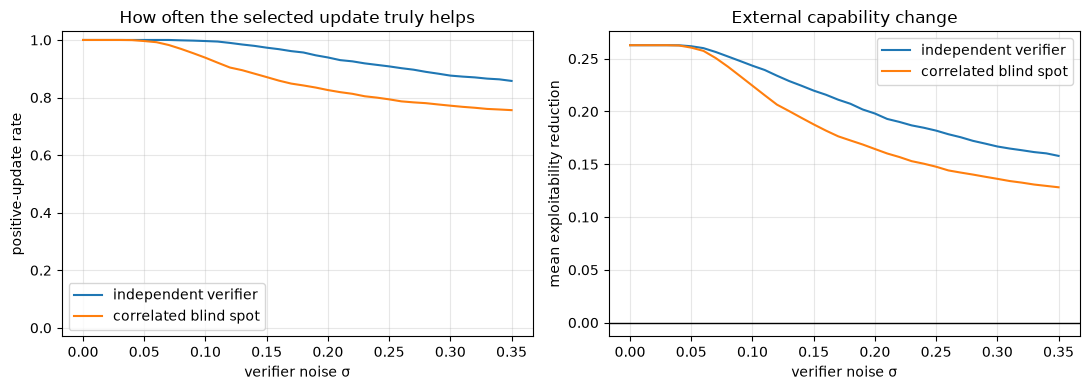

Across the independent-verifier sweep, added noise changed mean external gain by -0.105.
The biased verifier remains an audit failure even when repeated sampling makes its average score precise.


In [7]:
# [Result 02]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, results in [("independent verifier", clean), ("correlated blind spot", biased)]:
    axes[0].plot(noise_levels, [r['positive_rate'] for r in results], label=name)
    axes[1].plot(noise_levels, [r['mean_gain'] for r in results], label=name)
axes[0].set(title="How often the selected update truly helps", xlabel="verifier noise σ", ylabel="positive-update rate", ylim=(-.03, 1.03))
axes[1].axhline(0, color="black", lw=1)
axes[1].set(title="External capability change", xlabel="verifier noise σ", ylabel="mean exploitability reduction")
for ax in axes:
    ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()
delta = clean[-1]['mean_gain'] - clean[0]['mean_gain']
print(f"Across the independent-verifier sweep, added noise changed mean external gain by {delta:+.3f}.")
print("The biased verifier remains an audit failure even when repeated sampling makes its average score precise.")

**[Callout 02]**

> **Engineering Callout #2: More samples do not remove shared bias**
>
> Independent noise shrinks when scores are averaged. A systematic preference shared by generator and verifier does not. This is why verifier diversity means different evidence—execution, tests, rules, or independently labeled judgments—not several copies of the same judge.

**[Text 04]**

## What we built

The strategic experiment separated latest-policy performance from population robustness. The verifier experiment separated internal score from external capability and showed why both variance and correlated bias belong in the audit. This is a demonstration of the paper's qualitative design guidance, not an empirical validation of its theorem.

For a real self-play system, freeze the external benchmark and opponent suite before training; log verifier accuracy on an independently labeled slice; compare with a compute-matched non-self-play baseline so extra samples or updates are not miscredited to the curriculum; and preserve disagreement cases for inspection.